# TechStack: Data Preparation and ML Baseline

## 1. Project Overview

TechStack is designed as a scalable water-quality forecasting platform for multiple rivers. Because the prototype was developed under limited time, dataset availability, and computational constraints, this implementation uses historical Ganga River data as a baseline reference case.

This proof of concept validates the core data-to-model workflow before extending it to additional Indian rivers. The long-term architecture is:

**Multiple Rivers -> Standardized Data Pipeline -> Feature Engineering -> ML Models -> Water-Quality Forecasting**

The current implementation should therefore be read as a Ganga-based reference implementation, not as a model already trained across multiple rivers.

## 2. Environment Setup

### Import Libraries

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

### Configuration

In [2]:
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

### Project Root Detection

In [3]:
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
print("Project root:", ROOT)

Project root: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack


### Define Paths

In [4]:
RAW_WATER = ROOT / "data" / "raw" / "water_quality"
RAW_WEATHER = ROOT / "data" / "raw" / "weather"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
FIGURES = ROOT / "images"

### Create Required Directories

In [5]:
MODELS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
print("Directories ready.")

Directories ready.


### Verify Environment

In [6]:
for required_path in [RAW_WATER, RAW_WEATHER, PROCESSED, MODELS, FIGURES]:
    print(f"{required_path}: {required_path.exists()}")

C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\data\raw\water_quality: True
C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\data\raw\weather: True
C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\data\processed: True
C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\models: True
C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images: True


In [7]:
def save_and_show(fig, filename):
    """Save a figure and render the same figure in the notebook output."""
    output_path = FIGURES / filename
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    display(fig)
    plt.show()
    plt.close(fig)
    print(f"Saved and displayed: {output_path}")

## 3. Data Loading

The water-quality and weather masters were prepared in the earlier data-cleaning workflow. Weather is loaded for inspection but is not merged into this historical ML baseline because date compatibility has not been established.

### Load Water Quality Data

In [8]:
water_quality = pd.read_csv(PROCESSED / "water_quality_master.csv")

### Load Weather Data

In [9]:
weather = pd.read_csv(PROCESSED / "weather_master.csv")

### Load Prepared ML Dataset

In [10]:
prepared_model = pd.read_csv(PROCESSED / "model_dataset.csv")

### Display Dataset Shapes

In [11]:
print("Water-quality master:", water_quality.shape)
print("Weather master:", weather.shape)
print("Prepared model dataset:", prepared_model.shape)

Water-quality master: (413, 7)
Weather master: (1152, 14)
Prepared model dataset: (326, 6)


### Preview Data

In [12]:
display(water_quality.head())
display(prepared_model.head())

,state,station_name,year,dissolved_oxygen,bod,fecal_coliform,source_file
0,Uttarakhand,GANGA AT HARIDWAR D/S,2011.0,6.7,5.6,1150.0,rs_session-241_as196_1.1.csv
1,Uttarakhand,GANGA AT HARIDWAR D/S,2012.0,7.2,5.3,NaN,rs_session-241_as196_1.1.csv
2,Uttarakhand,GANGA AT HARIDWAR D/S,2013.0,6.5,5.2,NaN,rs_session-241_as196_1.1.csv
3,Uttarakhand,GANGA AT HARIDWAR D/S,2014.0,5.0,5.2,NaN,rs_session-241_as196_1.1.csv
4,Uttarakhand,GANGA AT HARIDWAR D/S,2015.0,9.2,2.8,580.0,rs_session-241_as196_1.1.csv


,state,year,dissolved_oxygen,bod,fecal_coliform,source_file
0,Uttarakhand,2011,6.7,5.6,1150.0,rs_session-241_as196_1.1.csv
1,Uttarakhand,2012,7.2,5.3,NaN,rs_session-241_as196_1.1.csv
2,Uttarakhand,2013,6.5,5.2,NaN,rs_session-241_as196_1.1.csv
3,Uttarakhand,2014,5.0,5.2,NaN,rs_session-241_as196_1.1.csv
4,Uttarakhand,2015,9.2,2.8,580.0,rs_session-241_as196_1.1.csv


### Display Dataset Columns

In [13]:
print("Water-quality columns:", water_quality.columns.tolist())
print("Weather columns:", weather.columns.tolist())
print("Prepared model columns:", prepared_model.columns.tolist())

Water-quality columns: ['state', 'station_name', 'year', 'dissolved_oxygen', 'bod', 'fecal_coliform', 'source_file']
Weather columns: ['location', 'time', 'temperature', 'dew_point', 'humidity', 'precipitation', 'snow', 'wind_direction', 'wind_speed', 'wind_gust', 'pressure', 'sunshine_duration', 'weather_code', 'source_file']
Prepared model columns: ['state', 'year', 'dissolved_oxygen', 'bod', 'fecal_coliform', 'source_file']


## 4. Data Quality and Validation

### Check Missing Values

In [14]:
display(water_quality.isna().sum().rename("missing_count").to_frame())

,missing_count
state,0
station_name,0
year,84
dissolved_oxygen,3
bod,363
fecal_coliform,31
source_file,0


### Check Duplicate Records

In [15]:
print("Duplicate water-quality rows:", water_quality.duplicated().sum())
print("Duplicate prepared model rows:", prepared_model.duplicated().sum())

Duplicate water-quality rows: 0
Duplicate prepared model rows: 20


### Display Data Types

In [16]:
display(water_quality.dtypes.rename("dtype").to_frame())

,dtype
state,str
station_name,str
year,float64
dissolved_oxygen,float64
bod,float64
fecal_coliform,float64
source_file,str


### Basic Dataset Summary

In [17]:
display(water_quality.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
state,413,5,Uttar Pradesh,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_name,413,107,GANGA AT HARIDWAR D/S,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,329.0,NaN,NaN,NaN,2018.088146,2.35069,2011.0,2018.0,2019.0,2020.0,2020.0
dissolved_oxygen,410.0,NaN,NaN,NaN,8.114976,1.175026,5.0,7.4125,8.1,8.9875,11.2
bod,50.0,NaN,NaN,NaN,4.47,1.373399,2.8,3.625,4.15,4.975,8.4
fecal_coliform,382.0,NaN,NaN,NaN,23847.180628,57571.671385,1.8,1300.0,6100.0,22000.0,592500.0
source_file,413,3,RS_Session_255_AU_90.1 (1).csv,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Exploratory Analysis

### Target Variable Distribution

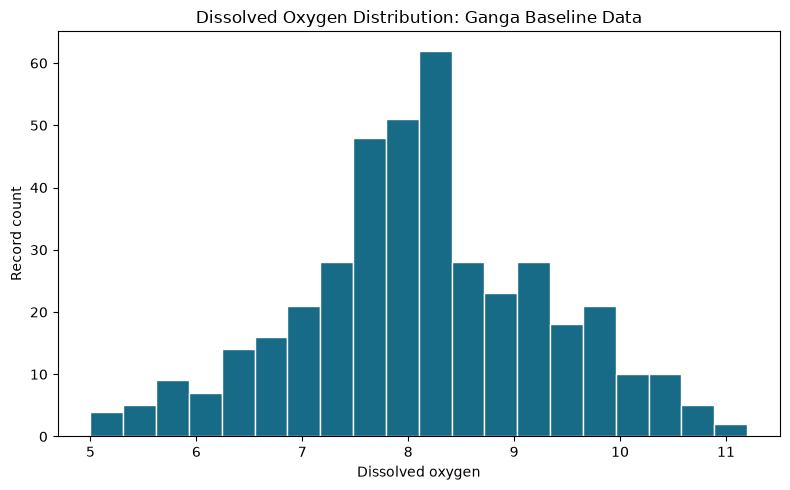

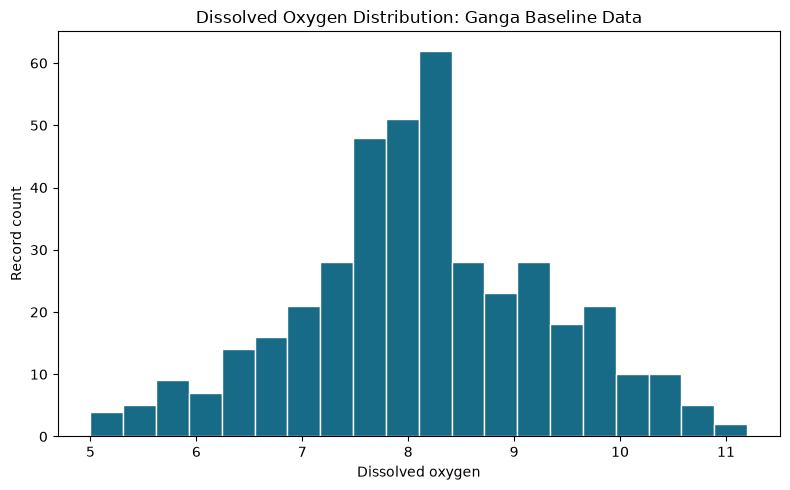

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\02_target_distribution.png


In [18]:
target_available = water_quality.dropna(subset=["dissolved_oxygen"])
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(target_available["dissolved_oxygen"], bins=20, color="#176b87", edgecolor="white")
ax.set_title("Dissolved Oxygen Distribution: Ganga Baseline Data")
ax.set_xlabel("Dissolved oxygen")
ax.set_ylabel("Record count")
save_and_show(fig, "02_target_distribution.png")

### Temporal Coverage

In [19]:
display(water_quality["year"].value_counts(dropna=False).sort_index().rename("record_count").to_frame())

,record_count
year,
2011.0,10
2012.0,10
2013.0,10
2014.0,10
2015.0,10
2018.0,93
2019.0,93
2020.0,93
NaN,84


### Missing Values Visualization

This chart identifies where the prepared water-quality master dataset has incomplete observations. Missing values are retained rather than fabricated.

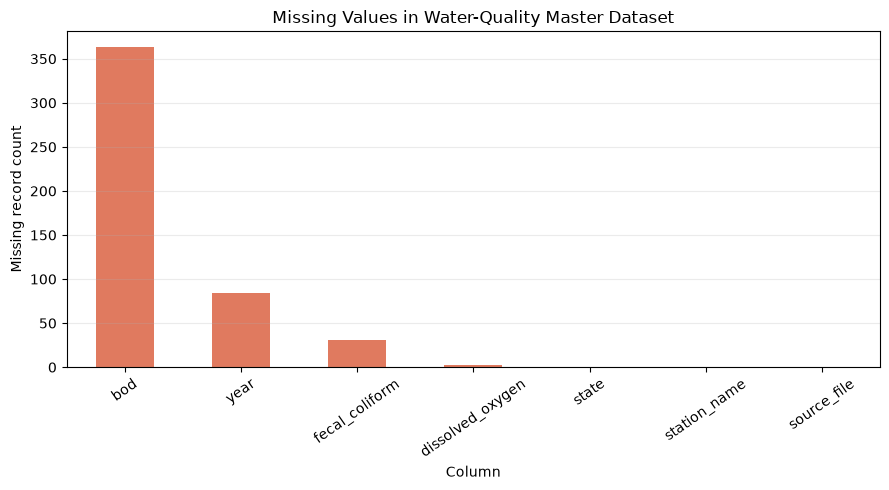

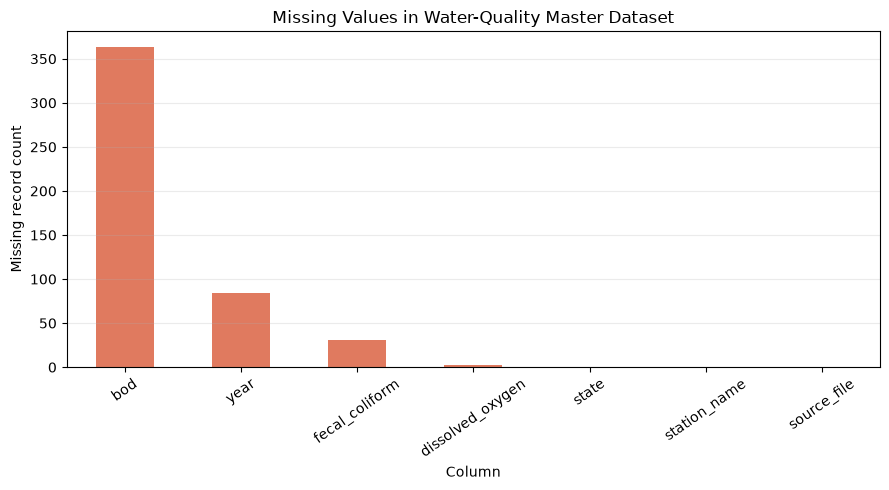

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\01_missing_values.png


In [20]:
missing_counts = water_quality.isna().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
missing_counts.plot(kind="bar", ax=ax, color="#e07a5f")
ax.set_title("Missing Values in Water-Quality Master Dataset")
ax.set_xlabel("Column")
ax.set_ylabel("Missing record count")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
save_and_show(fig, "01_missing_values.png")

### Target Variable Distribution

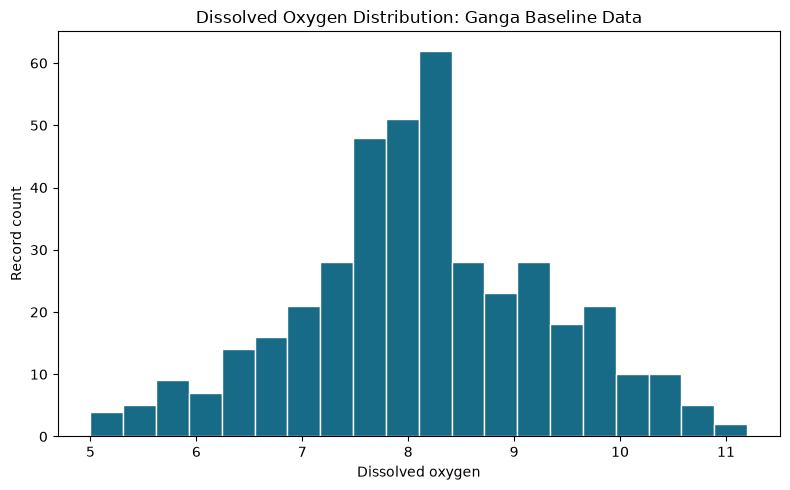

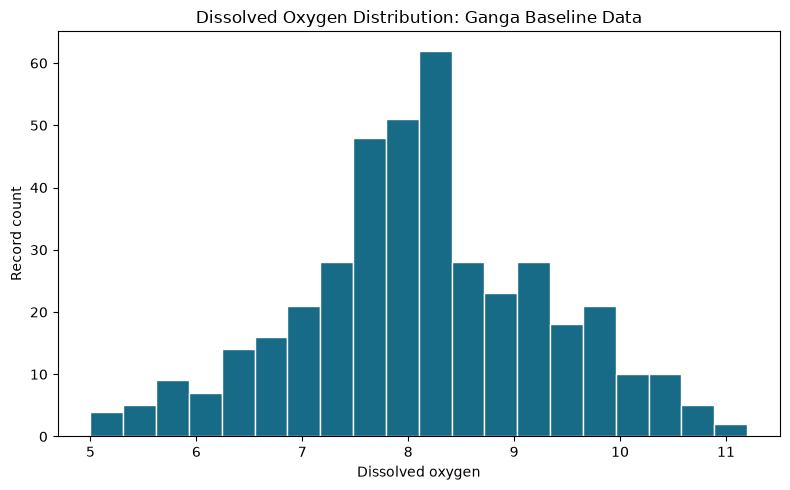

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\02_target_distribution.png


In [21]:
target_available = water_quality.dropna(subset=["dissolved_oxygen"])
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(target_available["dissolved_oxygen"], bins=20, color="#176b87", edgecolor="white")
ax.set_title("Dissolved Oxygen Distribution: Ganga Baseline Data")
ax.set_xlabel("Dissolved oxygen")
ax.set_ylabel("Record count")
save_and_show(fig, "02_target_distribution.png")

### Numerical Feature Distributions

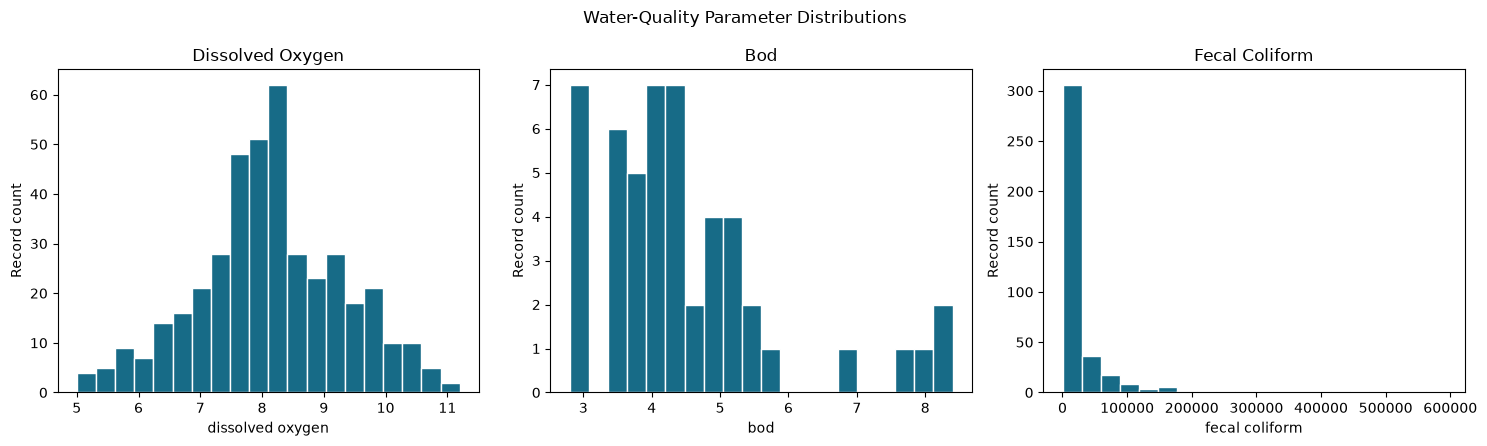

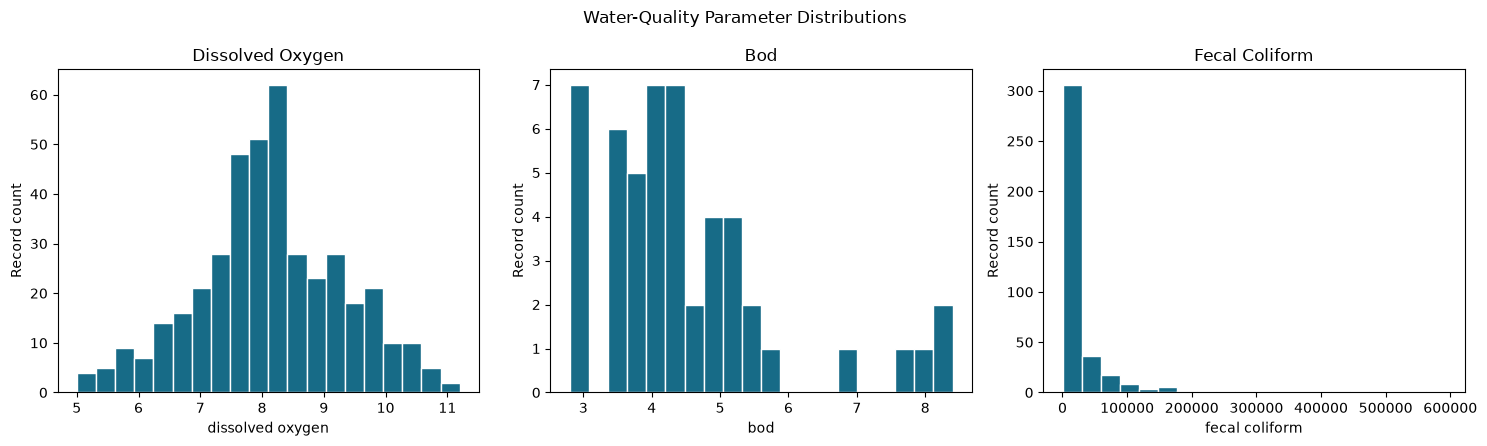

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\03_feature_distributions.png


In [22]:
numeric_parameters = ["dissolved_oxygen", "bod", "fecal_coliform"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, column in zip(axes, numeric_parameters):
    ax.hist(water_quality[column].dropna(), bins=20, color="#176b87", edgecolor="white")
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel(column.replace("_", " "))
    ax.set_ylabel("Record count")
fig.suptitle("Water-Quality Parameter Distributions")
save_and_show(fig, "03_feature_distributions.png")

### Water-Quality Parameter Boxplots

Boxplots show spread and potential extreme observations without silently removing them.

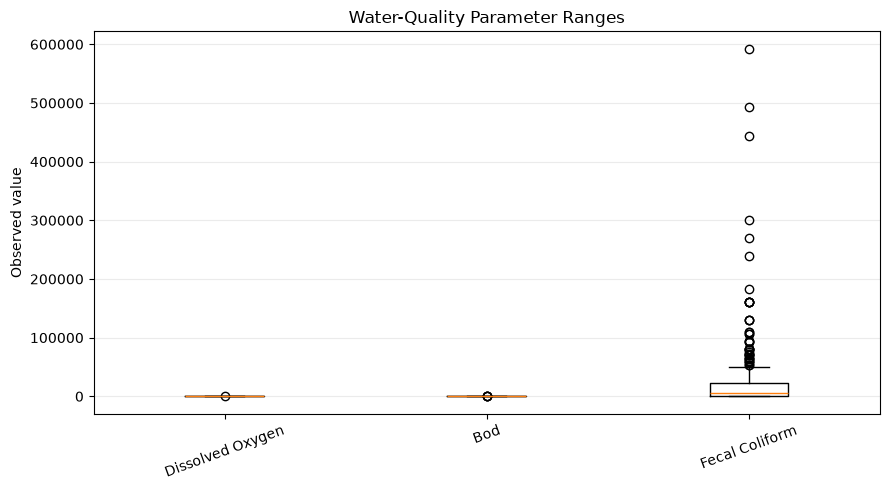

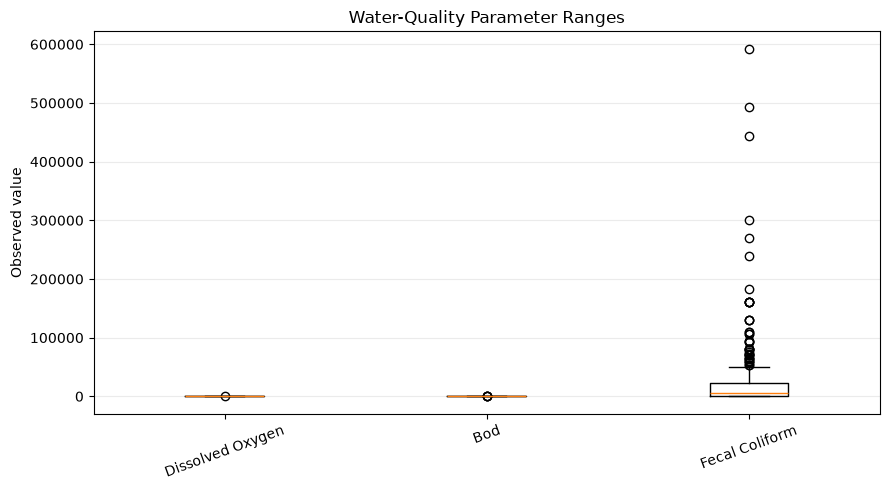

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\04_parameter_boxplots.png


In [23]:
box_data = [water_quality[column].dropna() for column in numeric_parameters]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(box_data, tick_labels=[column.replace("_", " ").title() for column in numeric_parameters], showfliers=True)
ax.set_title("Water-Quality Parameter Ranges")
ax.set_ylabel("Observed value")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
save_and_show(fig, "04_parameter_boxplots.png")

### Correlation Heatmap

This correlation view is descriptive only; it does not imply causal relationships.

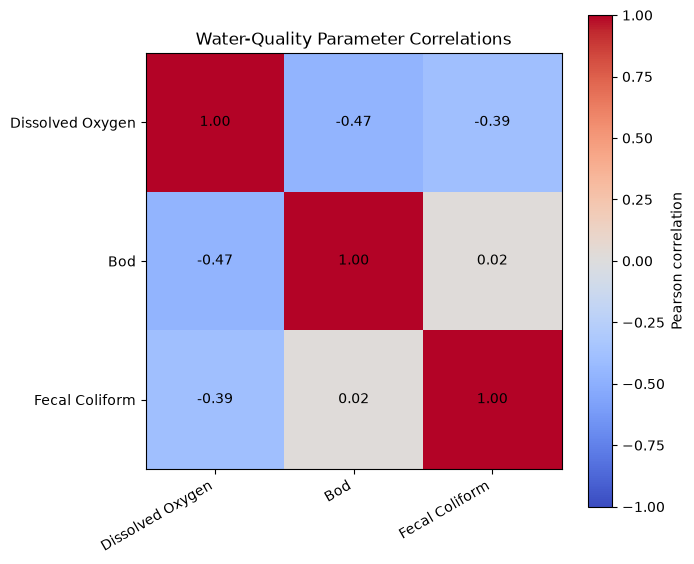

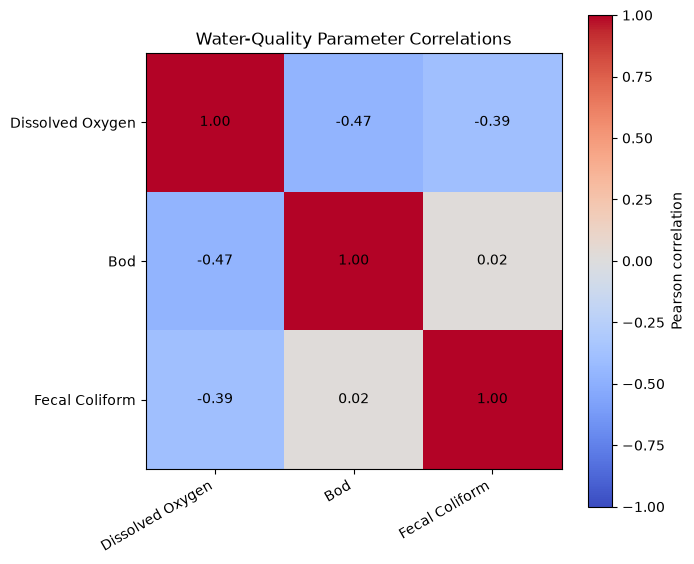

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\05_correlation_heatmap.png


In [24]:
correlation_data = water_quality[numeric_parameters].corr()
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(correlation_data, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_data.columns)), labels=[c.replace("_", " ").title() for c in correlation_data.columns], rotation=30, ha="right")
ax.set_yticks(range(len(correlation_data.index)), labels=[c.replace("_", " ").title() for c in correlation_data.index])
for row in range(len(correlation_data.index)):
    for column in range(len(correlation_data.columns)):
        ax.text(column, row, f"{correlation_data.iloc[row, column]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Water-Quality Parameter Correlations")
save_and_show(fig, "05_correlation_heatmap.png")

### Dissolved Oxygen Trend Over Time

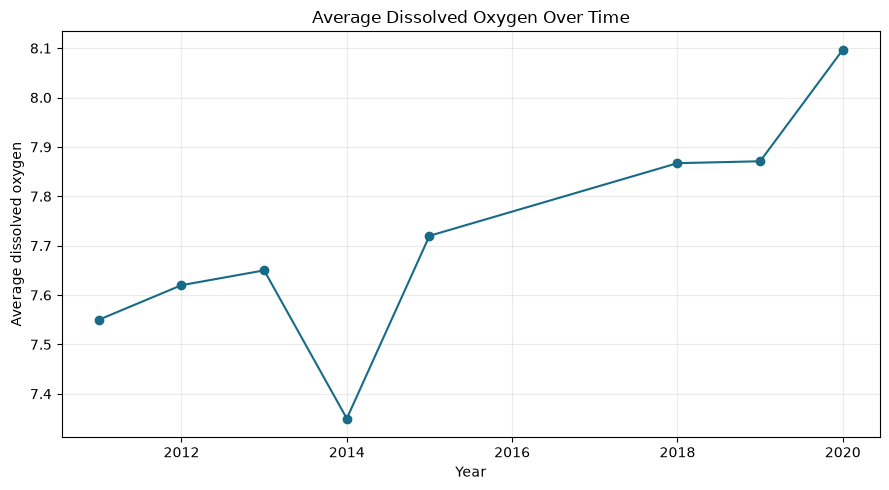

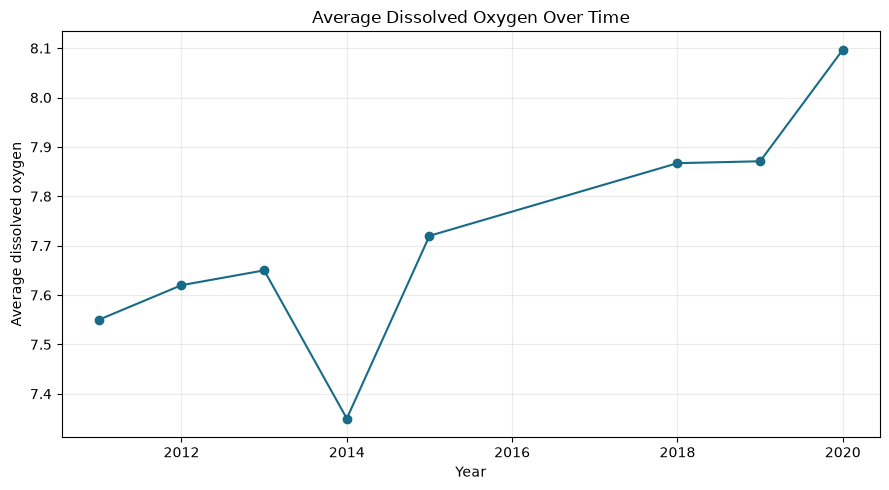

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\06_do_trend_over_time.png


In [25]:
yearly_target = target_available.dropna(subset=["year"]).groupby("year")["dissolved_oxygen"].mean()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly_target.index, yearly_target.values, marker="o", color="#176b87")
ax.set_title("Average Dissolved Oxygen Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Average dissolved oxygen")
ax.grid(alpha=0.25)
save_and_show(fig, "06_do_trend_over_time.png")

### Year-Wise Target Distribution

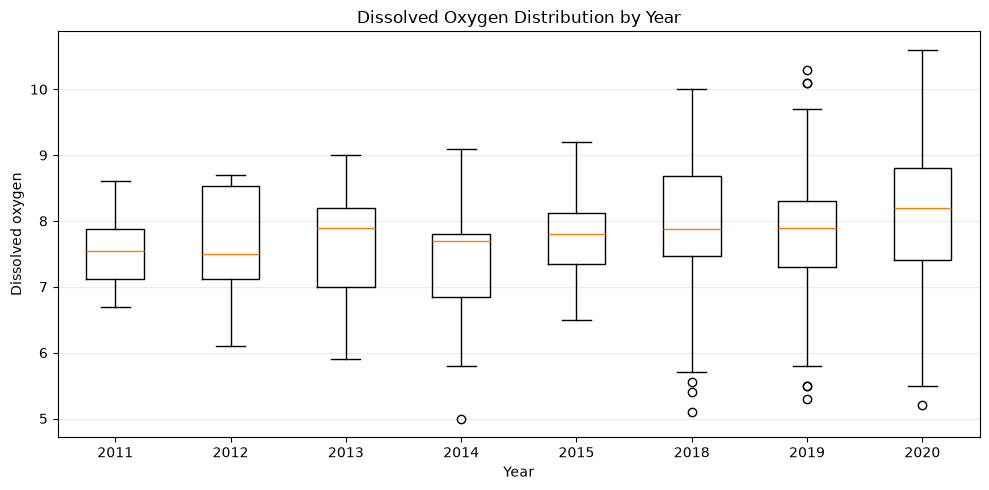

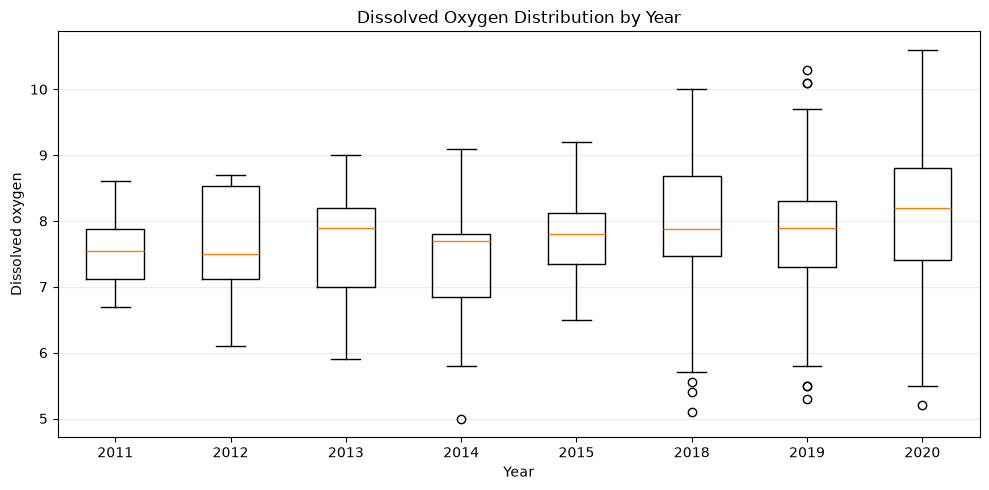

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\07_yearwise_target_distribution.png


In [26]:
year_values = [group["dissolved_oxygen"].dropna().values for _, group in target_available.dropna(subset=["year"]).groupby("year")]
year_labels = [str(int(year)) for year in sorted(target_available["year"].dropna().unique())]
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(year_values, tick_labels=year_labels, showfliers=True)
ax.set_title("Dissolved Oxygen Distribution by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Dissolved oxygen")
ax.grid(axis="y", alpha=0.25)
save_and_show(fig, "07_yearwise_target_distribution.png")

### Station-Wise Target Comparison

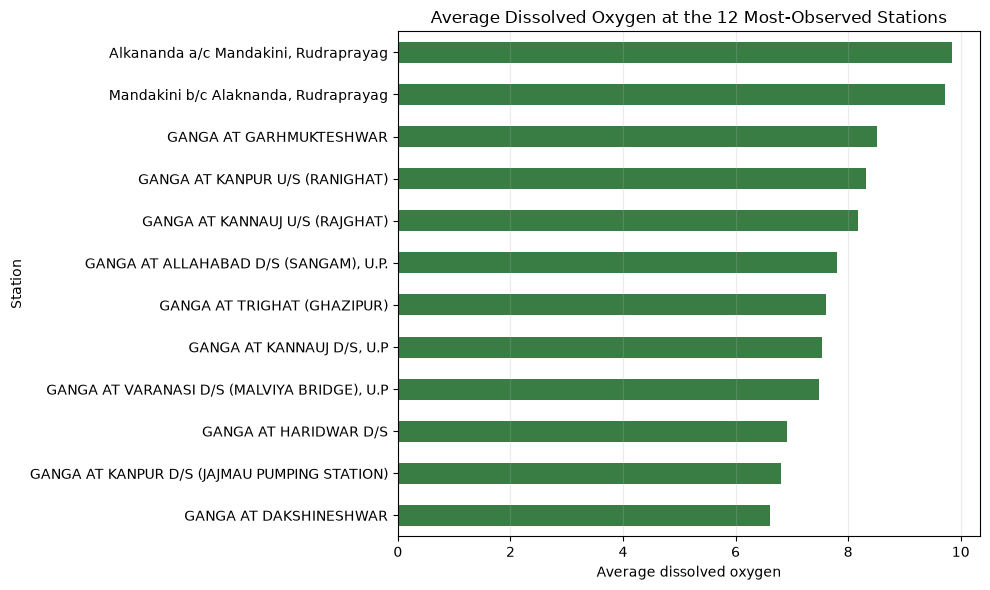

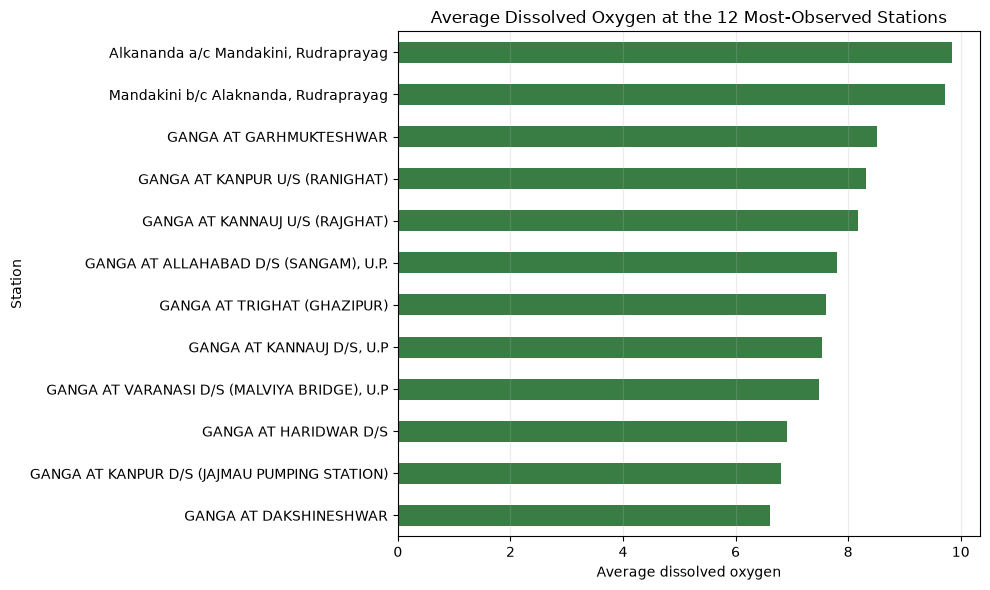

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\08_station_comparison.png


In [27]:
station_counts = target_available["station_name"].value_counts()
top_stations = station_counts.head(12).index
station_means = target_available[target_available["station_name"].isin(top_stations)].groupby("station_name")["dissolved_oxygen"].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
station_means.plot(kind="barh", ax=ax, color="#3a7d44")
ax.set_title("Average Dissolved Oxygen at the 12 Most-Observed Stations")
ax.set_xlabel("Average dissolved oxygen")
ax.set_ylabel("Station")
ax.grid(axis="x", alpha=0.25)
save_and_show(fig, "08_station_comparison.png")

### State-Wise Comparison

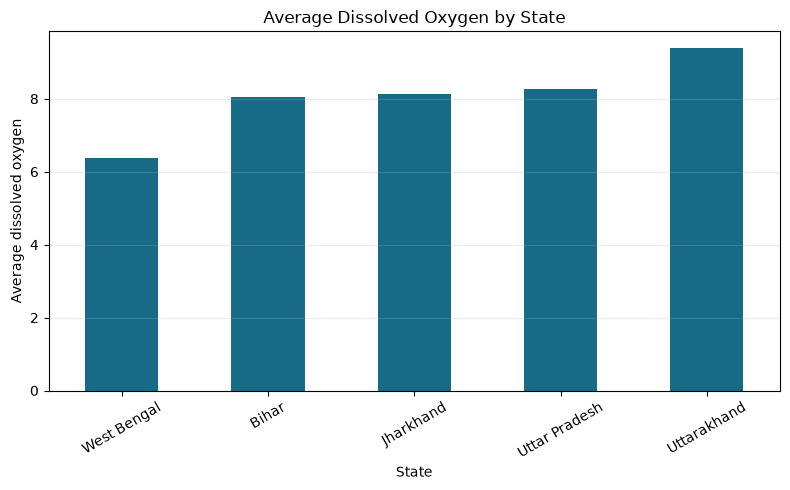

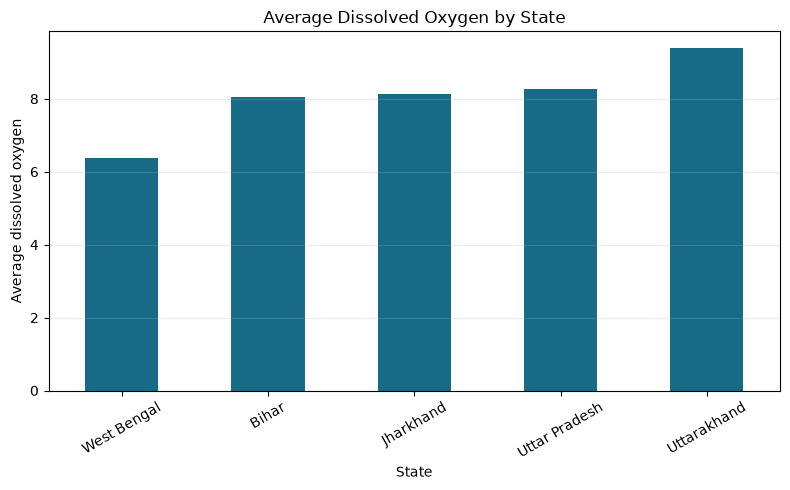

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\09_state_comparison.png


In [28]:
state_means = target_available.groupby("state")["dissolved_oxygen"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
state_means.plot(kind="bar", ax=ax, color="#176b87")
ax.set_title("Average Dissolved Oxygen by State")
ax.set_xlabel("State")
ax.set_ylabel("Average dissolved oxygen")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)
save_and_show(fig, "09_state_comparison.png")

## 6. Define the Machine Learning Problem

### Prediction Target

The target is `dissolved_oxygen`, treated as a continuous regression value.

### Input Features

The current baseline uses `state`, `station_name`, and `year`. These are the same features used by the existing workflow.

### Important Scope Note

This model is trained on the available Ganga River reference dataset. The pipeline is structured so future standardized river datasets can add a river identifier, river-specific stations, and river-aware feature engineering. This notebook does not claim multi-river training or generalization.

## 7. Train-Test Split

### Define Features

In [29]:
FEATURES = ["state", "station_name", "year"]
print("Features:", FEATURES)

Features: ['state', 'station_name', 'year']


### Define Target

In [30]:
TARGET = "dissolved_oxygen"
print("Target:", TARGET)

Target: dissolved_oxygen


### Create Training Dataset

In [31]:
model_data = water_quality[FEATURES + [TARGET, "source_file"]].dropna(subset=[TARGET, "year"]).copy()
model_data["year"] = model_data["year"].astype(int)
cutoff_year = model_data["year"].quantile(0.80)
train = model_data[model_data["year"] < cutoff_year].copy()
X_train = train[FEATURES]
y_train = train[TARGET]

### Create Testing Dataset

In [32]:
test = model_data[model_data["year"] >= cutoff_year].copy()
X_test = test[FEATURES]
y_test = test[TARGET]

### Display Split Information

In [33]:
print("Usable records:", len(model_data))
print("Excluded records:", len(water_quality) - len(model_data))
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training years:", sorted(train["year"].unique().tolist()))
print("Testing years:", sorted(test["year"].unique().tolist()))

Usable records: 326
Excluded records: 87
Training shape: (233, 3)
Testing shape: (93, 3)
Training years: [2011, 2012, 2013, 2014, 2015, 2018, 2019]
Testing years: [2020]


### Train-Test Target Distribution

The chronological split is inspected visually to make the evaluation period explicit.

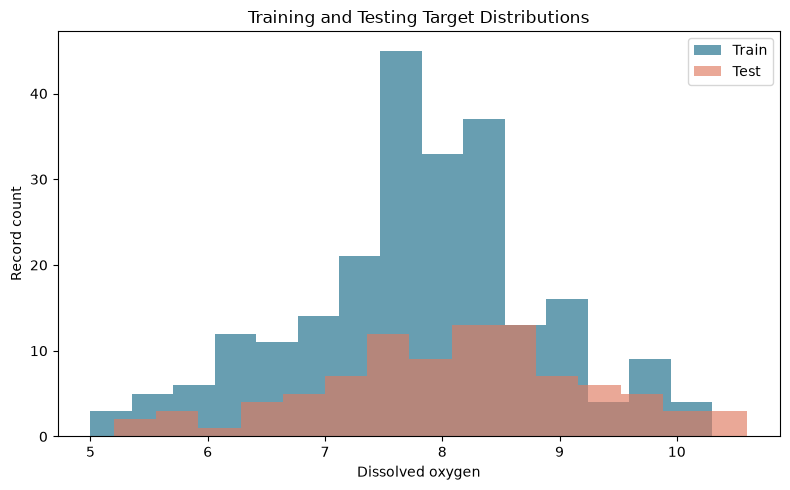

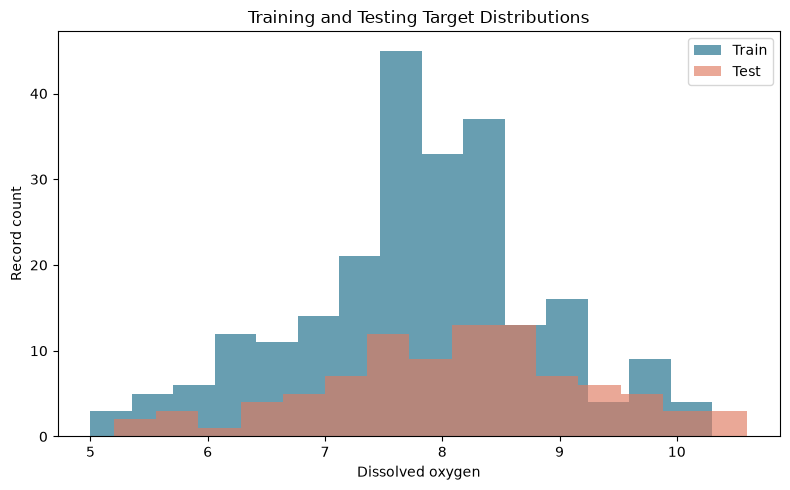

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\10_train_test_target_distribution.png


In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_train, bins=15, alpha=0.65, label="Train", color="#176b87")
ax.hist(y_test, bins=15, alpha=0.65, label="Test", color="#e07a5f")
ax.set_title("Training and Testing Target Distributions")
ax.set_xlabel("Dissolved oxygen")
ax.set_ylabel("Record count")
ax.legend()
save_and_show(fig, "10_train_test_target_distribution.png")

## 8. Feature Preprocessing

### Identify Categorical Features

In [35]:
categorical_features = ["state", "station_name"]
print(categorical_features)

['state', 'station_name']


### Identify Numerical Features

In [36]:
numerical_features = ["year"]
print(numerical_features)

['year']


### Categorical Preprocessing Pipeline

In [37]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

### Numerical Preprocessing Pipeline

In [38]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

### Combine Preprocessors

In [39]:
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numerical_pipeline, numerical_features),
])
print("Preprocessor ready.")

Preprocessor ready.


## 9. Model Definitions

### Linear Regression Definition

In [40]:
linear_regression = LinearRegression()

### Random Forest Definition

In [41]:
random_forest = RandomForestRegressor(
    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2
)

### Gradient Boosting Definition

In [42]:
gradient_boosting = GradientBoostingRegressor(
    random_state=RANDOM_STATE, n_estimators=150, max_depth=2, learning_rate=0.04, loss="huber"
)

### Model Registry

In [43]:
model_registry = {
    "Linear Regression": linear_regression,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
}

## 10. Model Training

### Define Training Helper Function

In [44]:
def build_pipeline(estimator):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

def train_model(estimator, name):
    fitted = build_pipeline(estimator)
    fitted.fit(X_train, y_train)
    print(f"{name} trained on {len(X_train)} records.")
    return fitted

### Train Linear Regression

In [45]:
linear_pipeline = train_model(linear_regression, "Linear Regression")

Linear Regression trained on 233 records.


### Train Random Forest

In [46]:
random_forest_pipeline = train_model(random_forest, "Random Forest")

Random Forest trained on 233 records.


### Train Gradient Boosting

In [47]:
gradient_boosting_pipeline = train_model(gradient_boosting, "Gradient Boosting")

Gradient Boosting trained on 233 records.


### Store Trained Pipelines

In [48]:
trained_pipelines = {
    "Linear Regression": linear_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline,
}

## 11. Model Predictions

### Predict with Linear Regression

In [49]:
linear_predictions = linear_pipeline.predict(X_test)

### Predict with Random Forest

In [50]:
random_forest_predictions = random_forest_pipeline.predict(X_test)

### Predict with Gradient Boosting

In [51]:
gradient_boosting_predictions = gradient_boosting_pipeline.predict(X_test)

### Store Predictions

In [52]:
predictions = {
    "Linear Regression": linear_predictions,
    "Random Forest": random_forest_predictions,
    "Gradient Boosting": gradient_boosting_predictions,
}

## 12. Model Evaluation

### Define Evaluation Function

In [53]:
def evaluate_predictions(actual, predicted, model_name):
    return {
        "model": model_name,
        "mae": mean_absolute_error(actual, predicted),
        "rmse": np.sqrt(mean_squared_error(actual, predicted)),
        "r2": r2_score(actual, predicted),
    }

### Evaluate Linear Regression

In [54]:
linear_metrics = evaluate_predictions(y_test, linear_predictions, "Linear Regression")
print(linear_metrics)

{'model': 'Linear Regression', 'mae': 0.48781470582039177, 'rmse': np.float64(0.6049026455534323), 'r2': 0.7300306874558002}


### Evaluate Random Forest

In [55]:
random_forest_metrics = evaluate_predictions(y_test, random_forest_predictions, "Random Forest")
print(random_forest_metrics)

{'model': 'Random Forest', 'mae': 0.4945891599433523, 'rmse': np.float64(0.6282060074524555), 'r2': 0.7088293451535657}


### Evaluate Gradient Boosting

In [56]:
gradient_boosting_metrics = evaluate_predictions(y_test, gradient_boosting_predictions, "Gradient Boosting")
print(gradient_boosting_metrics)

{'model': 'Gradient Boosting', 'mae': 0.5992716295183023, 'rmse': np.float64(0.7395098215336472), 'r2': 0.5965113474466548}


### Create Model Comparison Table

In [57]:
results = pd.DataFrame([linear_metrics, random_forest_metrics, gradient_boosting_metrics])
results = results.sort_values(["rmse", "mae"]).reset_index(drop=True)
display(results)

,model,mae,rmse,r2
0,Linear Regression,0.487815,0.604903,0.730031
1,Random Forest,0.494589,0.628206,0.708829
2,Gradient Boosting,0.599272,0.739510,0.596511


## 13. Model Comparison and Selection

The selected model is the model with the lowest RMSE on the chronological holdout, using MAE as a tie-breaker. This choice describes performance on the current Ganga baseline dataset only. It is not a claim that the same model will be best for every river or future data release.

In [58]:
best_model_name = results.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]
best_predictions = predictions[best_model_name]
print("Selected model on this baseline:", best_model_name)

Selected model on this baseline: Linear Regression


### Actual vs Predicted for Each Model

These three panels show model-specific behavior on the same chronological holdout.

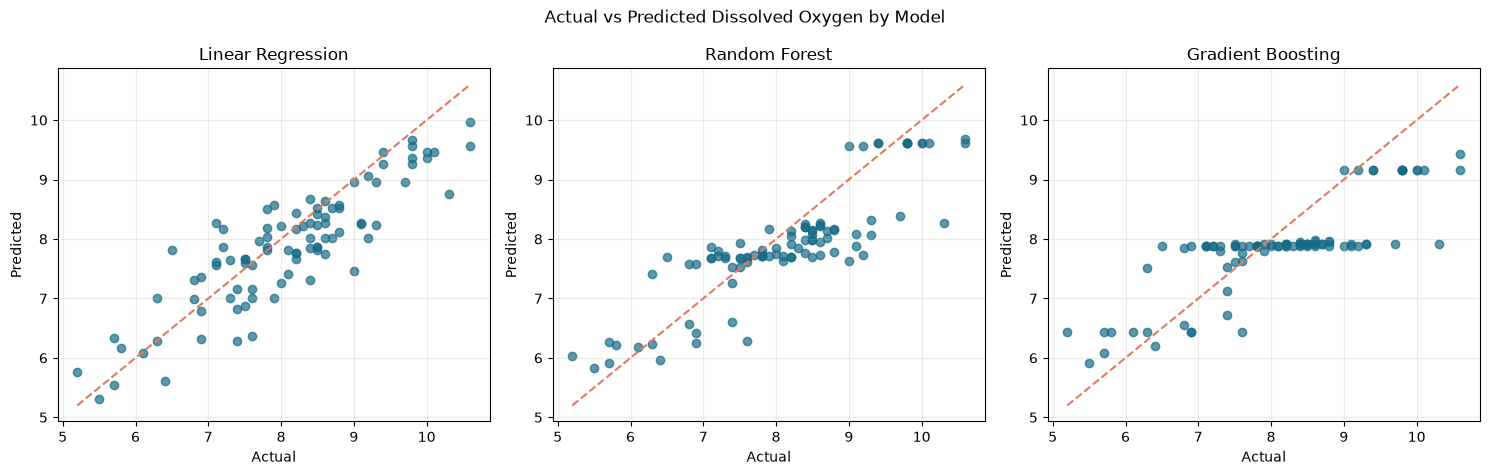

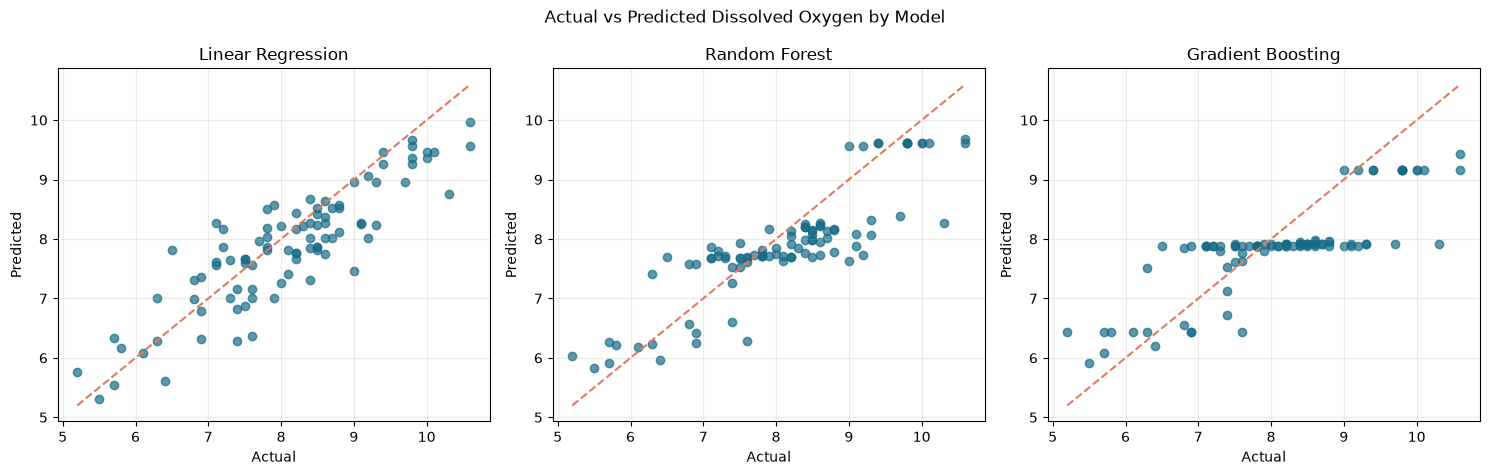

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\11_model_predictions_comparison.png


In [59]:
model_prediction_pairs = [("Linear Regression", linear_predictions), ("Random Forest", random_forest_predictions), ("Gradient Boosting", gradient_boosting_predictions)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (name, prediction) in zip(axes, model_prediction_pairs):
    ax.scatter(y_test, prediction, alpha=0.7, color="#176b87")
    lo = min(y_test.min(), prediction.min())
    hi = max(y_test.max(), prediction.max())
    ax.plot([lo, hi], [lo, hi], "--", color="#e07a5f")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
fig.suptitle("Actual vs Predicted Dissolved Oxygen by Model")
save_and_show(fig, "11_model_predictions_comparison.png")

### Linear Regression Predictions

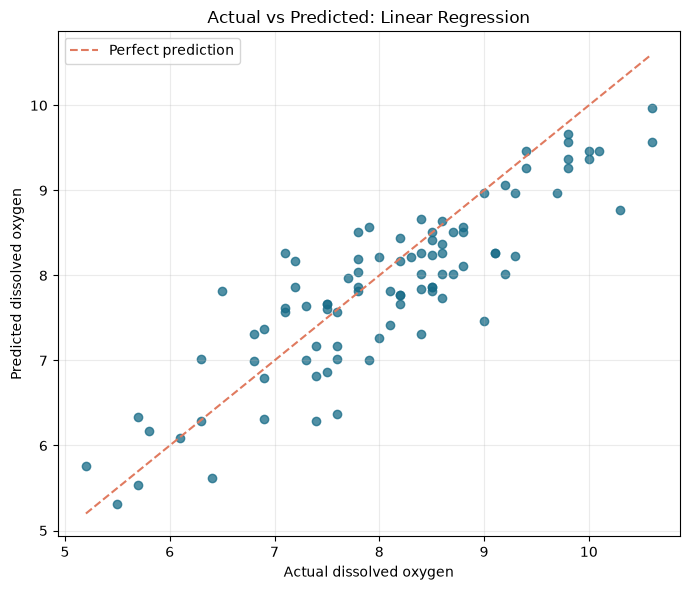

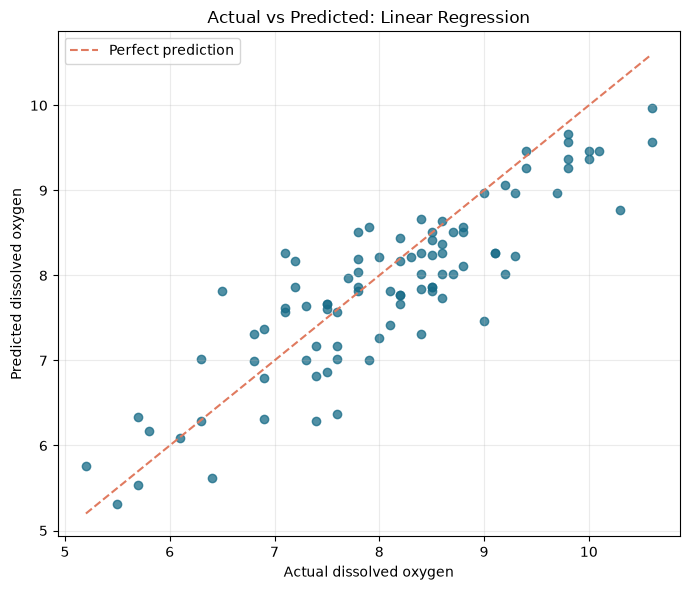

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\12_linear_regression_predictions.png


In [60]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, linear_predictions, alpha=0.75, color="#176b87")
lo, hi = min(y_test.min(), linear_predictions.min()), max(y_test.max(), linear_predictions.max())
ax.plot([lo, hi], [lo, hi], "--", color="#e07a5f", label="Perfect prediction")
ax.set_title("Actual vs Predicted: Linear Regression")
ax.set_xlabel("Actual dissolved oxygen")
ax.set_ylabel("Predicted dissolved oxygen")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "12_linear_regression_predictions.png")

### Random Forest Predictions

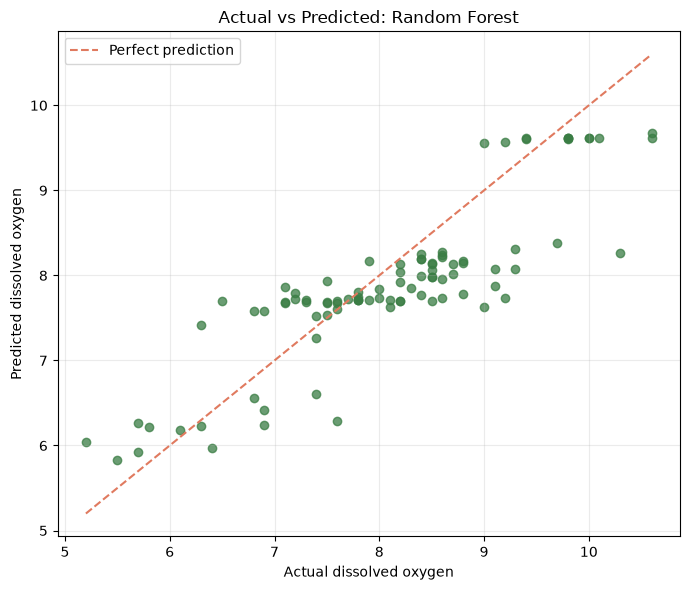

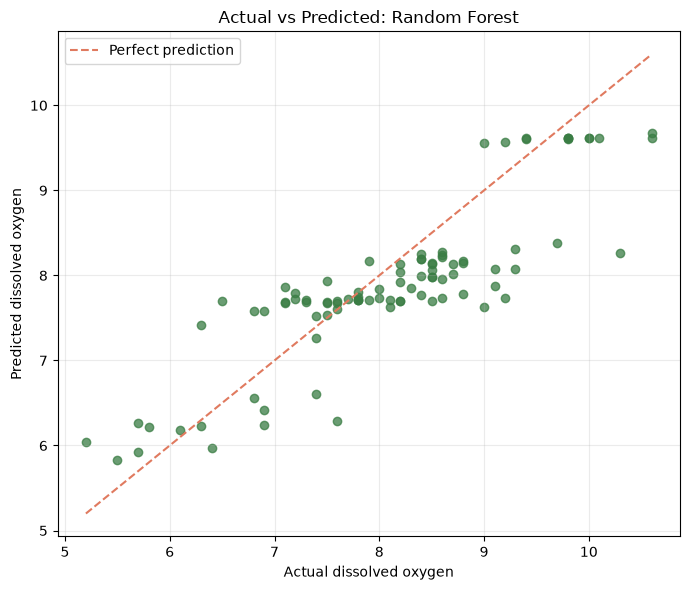

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\13_random_forest_predictions.png


In [61]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, random_forest_predictions, alpha=0.75, color="#3a7d44")
lo, hi = min(y_test.min(), random_forest_predictions.min()), max(y_test.max(), random_forest_predictions.max())
ax.plot([lo, hi], [lo, hi], "--", color="#e07a5f", label="Perfect prediction")
ax.set_title("Actual vs Predicted: Random Forest")
ax.set_xlabel("Actual dissolved oxygen")
ax.set_ylabel("Predicted dissolved oxygen")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "13_random_forest_predictions.png")

### Gradient Boosting Predictions

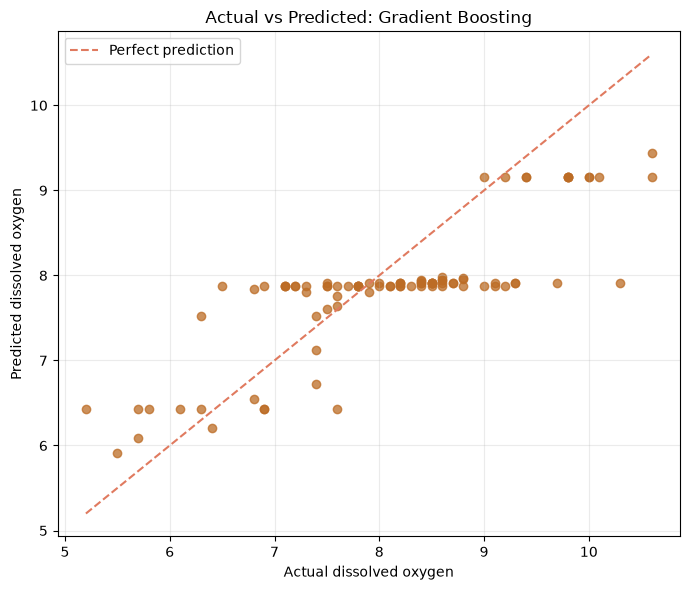

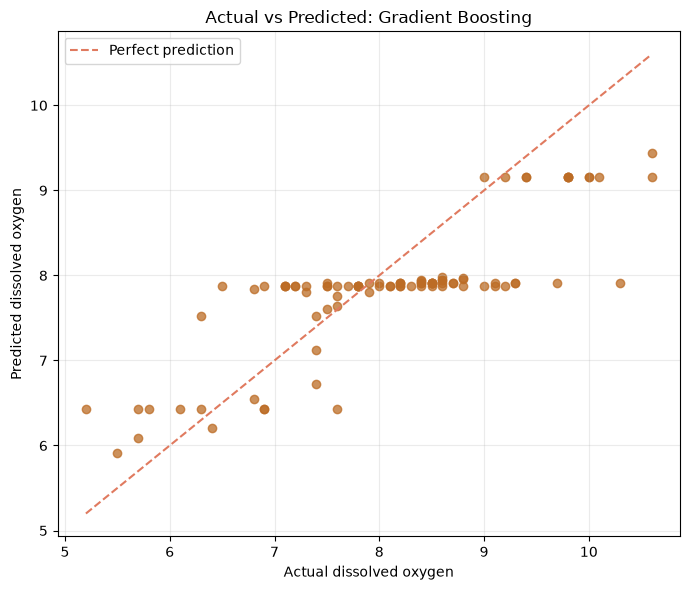

Saved and displayed: C:\Users\AARYA PATEL\OneDrive\Desktop\Github\TechStack\images\14_gradient_boosting_predictions.png


In [62]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, gradient_boosting_predictions, alpha=0.75, color="#bc6c25")
lo, hi = min(y_test.min(), gradient_boosting_predictions.min()), max(y_test.max(), gradient_boosting_predictions.max())
ax.plot([lo, hi], [lo, hi], "--", color="#e07a5f", label="Perfect prediction")
ax.set_title("Actual vs Predicted: Gradient Boosting")
ax.set_xlabel("Actual dissolved oxygen")
ax.set_ylabel("Predicted dissolved oxygen")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "14_gradient_boosting_predictions.png")

### Selected Best-Model Predictions

### Best-Model Residual Plot

### Best-Model Residual Distribution

NameError: name 'residuals' is not defined

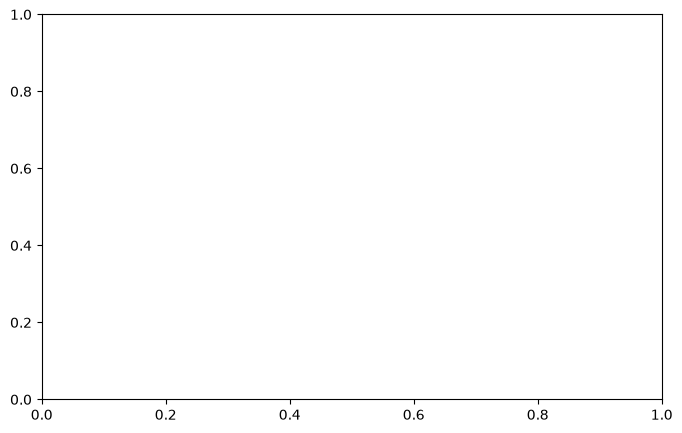

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=18, color="#3a7d44", edgecolor="white")
ax.axvline(0, linestyle="--", color="#e07a5f")
ax.set_title(f"Residual Distribution: {best_model_name}")
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("Record count")
save_and_show(fig, "17_best_model_residual_distribution.png")

## 14. Diagnostics and Visualization

### Model Comparison Chart

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ["mae", "rmse", "r2"]):
    ordered = results.sort_values(metric, ascending=(metric != "r2"))
    ax.bar(ordered["model"], ordered[metric], color=["#176b87", "#e07a5f", "#3a7d44"])
    ax.set_title(metric.upper())
    ax.set_xlabel("Model")
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Chronological Holdout Model Comparison: Ganga Baseline")
save_and_show(fig, "18_model_comparison.png")

### Actual vs Predicted

### Residual Plot

In [ ]:
residuals = y_test.to_numpy() - best_predictions
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best_predictions, residuals, alpha=0.75, color="#3a7d44")
ax.axhline(0, linestyle="--", color="#e07a5f")
ax.set_title(f"Residual Diagnostics: {best_model_name}")
ax.set_xlabel("Predicted dissolved oxygen")
ax.set_ylabel("Residual (actual - predicted)")
ax.grid(alpha=0.25)
save_and_show(fig, "20_residual_diagnostics.png")

## 15. Save Results and Artifacts

### Save Model Comparison Results

In [ ]:
results.to_csv(PROCESSED / "model_comparison.csv", index=False)

### Save Best Model and Supporting Pipelines

In [ ]:
for name, pipeline in trained_pipelines.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(pipeline, MODELS / f"{safe_name}_water_quality.joblib")
joblib.dump(best_pipeline, MODELS / "best_water_quality_model.joblib")

### Save Predictions

In [ ]:
prediction_output = test[["state", "station_name", "year", TARGET, "source_file"]].copy()
prediction_output["prediction"] = best_predictions
prediction_output["residual"] = residuals
prediction_output.to_csv(PROCESSED / "best_model_predictions.csv", index=False)

### Save Metadata

In [ ]:
metadata = {
    "project_scope": "Ganga River baseline/reference implementation",
    "target": TARGET,
    "features": FEATURES,
    "models_compared": list(trained_pipelines),
    "selected_model": best_model_name,
    "train_years": sorted(train["year"].unique().tolist()),
    "test_years": sorted(test["year"].unique().tolist()),
    "metrics": results.to_dict(orient="records"),
    "limitations": [
        "The current model is trained on the available Ganga baseline data, not multiple rivers.",
        "Weather was not merged because historical date compatibility is unestablished.",
        "Satellite features are excluded from the initial model.",
        "Synthetic IoT readings are not historical ground truth.",
    ],
}
(MODELS / "model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

### Verify Saved Files

In [ ]:
for output_path in [
    PROCESSED / "model_comparison.csv",
    PROCESSED / "best_model_predictions.csv",
    MODELS / "best_water_quality_model.joblib",
    MODELS / "model_metadata.json",
    *sorted(FIGURES.glob("*.png")),
]:
    print(output_path, output_path.exists())

## 16. Current Limitations

- The current prototype uses Ganga River data as the baseline reference case.
- Standardized multi-river datasets are not yet available in this workflow.
- River-specific environmental characteristics may affect model performance.
- More historical data is required to assess true multi-river generalization.
- Results should be interpreted as baseline prototype results, not universal performance claims.
- Weather remains separate until compatible historical dates are established.
- Satellite data is not included in the initial ML model.

## 17. Future Multi-River Roadmap

1. Integrate datasets from additional Indian rivers.
2. Add a river identifier to standardized records.
3. Standardize stations and monitoring data across rivers.
4. Develop river-aware feature engineering.
5. Evaluate generalized versus river-specific models.
6. Expand forecasting targets.
7. Build larger historical datasets and stronger validation periods.

## 18. Final Summary

A working ML baseline has been developed for the TechStack proof of concept. Ganga River data is used as the current reference implementation, and the notebook demonstrates the core data loading, validation, preprocessing, training, evaluation, diagnostics, and artifact-saving workflow. The architecture remains intended for future expansion to multiple rivers; this notebook does not claim that multi-river training has already been completed.